In [6]:
# Initialize Otter
import otter
grader = otter.Notebook("intro2PyTorch.ipynb")

## Lecture Section

In this lecture, we will cover neural networks using `PyTorch`.
We will cover:
* PyTorch vs. Keras
* Autograd
* Building models with `nn.Module`
* Feedforward network — regression
* Recurrent Neural Networks (RNNs)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu130


### PyTorch vs. Keras — What's Different?

In Keras, you define a model, call `.compile()`, then `.fit()` — Keras handles the training loop for you. This is great for getting started quickly.

PyTorch takes a **lower-level** approach. You write the training loop yourself, which gives you much more control over:
- How gradients are computed and applied
- Custom loss functions and optimizers
- Per-step logic (e.g., gradient clipping, dynamic learning rates)
- Debugging — you can inspect values at every single step

This is why PyTorch is the dominant framework in research. The trade-off is more code.

| | Keras | PyTorch |
|---|---|---|
| Training loop | Hidden inside `.fit()` | You write it explicitly |
| Model definition | `Sequential` or functional API | Subclass `nn.Module` |
| Gradients | Automatic, invisible | Explicit: `loss.backward()`, `optimizer.step()` |
| Flexibility | High-level, less control | Low-level, full control |
| Best for | Quick prototyping, production | Research, custom architectures |

### Tensors

The fundamental data structure in PyTorch is the **tensor** — essentially a numpy array, but with two key extra abilities:
1. It can live on a **GPU** for fast computation
2. It can track **gradients** for automatic differentiation

Most operations you know from numpy have direct equivalents in PyTorch.

In [8]:
# Creating tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("a:", a)
print("b:", b)
print("a + b:", a + b)
print("a * b:", a * b)
print("dot product:", torch.dot(a, b))
print("dtype:", a.dtype)
print("shape:", a.shape)

a: tensor([1., 2., 3.])
b: tensor([4., 5., 6.])
a + b: tensor([5., 7., 9.])
a * b: tensor([ 4., 10., 18.])
dot product: tensor(32.)
dtype: torch.float32
shape: torch.Size([3])


In [9]:
# Converting between numpy and torch
arr = np.array([1.0, 2.0, 3.0])

t = torch.from_numpy(arr)   # numpy → tensor
back = t.numpy()             # tensor → numpy

print("numpy array:", arr)
print("as tensor:",   t)
print("back to numpy:", back)

numpy array: [1. 2. 3.]
as tensor: tensor([1., 2., 3.], dtype=torch.float64)
back to numpy: [1. 2. 3.]


### Automatic Differentiation (Autograd)

This is the feature that makes PyTorch powerful for neural networks. When you set `requires_grad=True` on a tensor, PyTorch tracks every operation performed on it and can automatically compute the gradient of any output with respect to that tensor.

This is what backpropagation uses under the hood — PyTorch builds a **computation graph** as you do the forward pass, then `.backward()` traverses it in reverse to compute gradients via the chain rule.

You never have to derive gradients by hand.

In [10]:
# Simple example: y = x^2 + 3x,  dy/dx = 2x + 3
x = torch.tensor(4.0, requires_grad=True)
y = x**2 + 3*x

print(f"x = {x.item()}")
print(f"y = x² + 3x = {y.item()}")

# Compute gradients
y.backward()

print(f"dy/dx = 2x + 3 = {x.grad.item()}  (expected: {2*4 + 3})")

x = 4.0
y = x² + 3x = 28.0
dy/dx = 2x + 3 = 11.0  (expected: 11)


In [11]:
# IMPORTANT: gradients accumulate by default — you must zero them before each backward pass
x = torch.tensor(4.0, requires_grad=True)

for step in range(3):
    y = x**2 + 3*x
    y.backward()
    print(f"Step {step+1} — grad (accumulated): {x.grad.item()}")

print()
x = torch.tensor(4.0, requires_grad=True)
for step in range(3):
    y = x**2 + 3*x
    y.backward()
    print(f"Step {step+1} — grad (zeroed):      {x.grad.item()}")
    x.grad.zero_()  # zero the gradient after reading it

Step 1 — grad (accumulated): 11.0
Step 2 — grad (accumulated): 22.0
Step 3 — grad (accumulated): 33.0

Step 1 — grad (zeroed):      11.0
Step 2 — grad (zeroed):      11.0
Step 3 — grad (zeroed):      11.0


This is why you'll always see `optimizer.zero_grad()` at the start of every training step in PyTorch — if you forget it, gradients pile up across batches and your model won't train correctly.

### Building Models with `nn.Module`

In PyTorch, you define a model by subclassing `nn.Module`. You need to implement two methods:

- `__init__` — define the layers as attributes
- `forward` — define how data flows through those layers

PyTorch will automatically handle `backward()` based on whatever you write in `forward()`.

This is the key conceptual difference from Keras — **you explicitly define the forward pass**, rather than just stacking layers.

In [12]:
class FeedforwardNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)  # fully connected layer
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)           # output: single value (regression)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))  # input → hidden 1
        x = self.relu(self.fc2(x))  # hidden 1 → hidden 2
        x = self.fc3(x)             # hidden 2 → output (no activation for regression)
        return x

# Instantiate and inspect
net = FeedforwardNet(input_size=8)
print(net)

FeedforwardNet(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


### The Explicit Training Loop

In Keras you called `.fit()`. In PyTorch, you write this yourself. Every training step follows the same five lines:

```python
optimizer.zero_grad()   # 1. clear old gradients
output = model(X)       # 2. forward pass
loss = criterion(output, y)  # 3. compute loss
loss.backward()         # 4. backpropagate
optimizer.step()        # 5. update weights
```

Let's train the feedforward network on the California housing dataset.

In [13]:
# Load and prepare data
housing = fetch_california_housing()
X, y = housing.data, housing.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# DataLoader — handles batching automatically
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Training samples: {X_train_t.shape[0]}")
print(f"Features:         {X_train_t.shape[1]}")

Training samples: 16512
Features:         8


In [14]:
torch.manual_seed(42)

model     = FeedforwardNet(input_size=X_train_t.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []

for epoch in range(50):
    model.train()          # set model to training mode
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()            # 1. clear gradients
        preds = model(X_batch)           # 2. forward pass
        loss  = criterion(preds, y_batch) # 3. compute loss
        loss.backward()                  # 4. backpropagate
        optimizer.step()                 # 5. update weights
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/50  |  Train MSE: {avg_loss:.4f}  |  Train RMSE: {avg_loss**0.5:.4f}")

Epoch  10/50  |  Train MSE: 0.3057  |  Train RMSE: 0.5529
Epoch  20/50  |  Train MSE: 0.2874  |  Train RMSE: 0.5361
Epoch  30/50  |  Train MSE: 0.2706  |  Train RMSE: 0.5202
Epoch  40/50  |  Train MSE: 0.2624  |  Train RMSE: 0.5123
Epoch  50/50  |  Train MSE: 0.2553  |  Train RMSE: 0.5052


Test RMSE: 0.5251


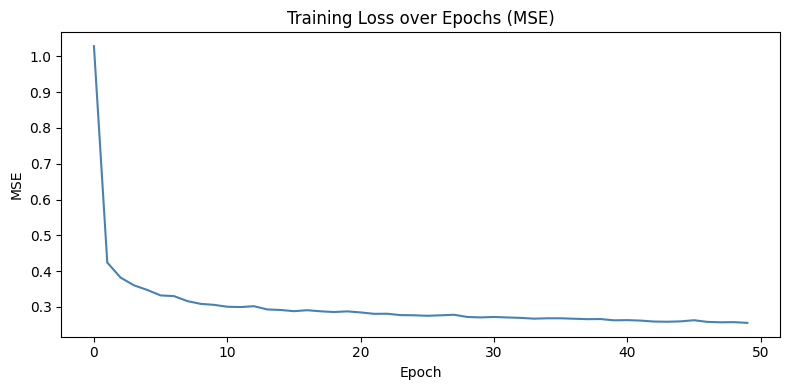

In [15]:
model.eval()                          # set to eval mode — disables dropout etc.
with torch.no_grad():                 # no_grad: don't track gradients during evaluation
    test_preds = model(X_test_t)
    test_mse   = criterion(test_preds, y_test_t).item()

print(f"Test RMSE: {test_mse**0.5:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title('Training Loss over Epochs (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

Two things to notice:
- `model.eval()` — switches the model to evaluation mode. Some layers (like Dropout and BatchNorm) behave differently during training vs. inference. Always set this before predicting.
- `torch.no_grad()` — tells PyTorch not to build a computation graph. Since we're not backpropagating, this saves memory and speeds things up.

### Recurrent Neural Networks (RNNs)

Recall from the Keras lecture: a **Recurrent Neural Network** uses a spatial linear transformation to retain **order and context**. Unlike feedforward networks — where each input is processed independently — an RNN maintains a **hidden state** that gets updated at each time step, carrying information forward through the sequence.

At each step $t$, the RNN computes:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

Where:
- $x_t$ is the input at time step $t$
- $h_{t-1}$ is the hidden state from the previous step (the "memory")
- $W_x$, $W_h$, $b$ are learned parameters

This makes RNNs natural for:
- Time series prediction
- Text (each word depends on previous words)
- Any data where **order matters**

#### Why PyTorch for RNNs?

PyTorch's explicit training loop makes RNNs much easier to work with than Keras — you can see exactly what the hidden state is doing at every step, and you have full control over how it's initialized and passed between steps.

#### Example: Predicting a Sine Wave

We'll train an RNN to predict the next value in a sine wave given a short window of past values. This is a clean toy example that demonstrates sequence modeling.

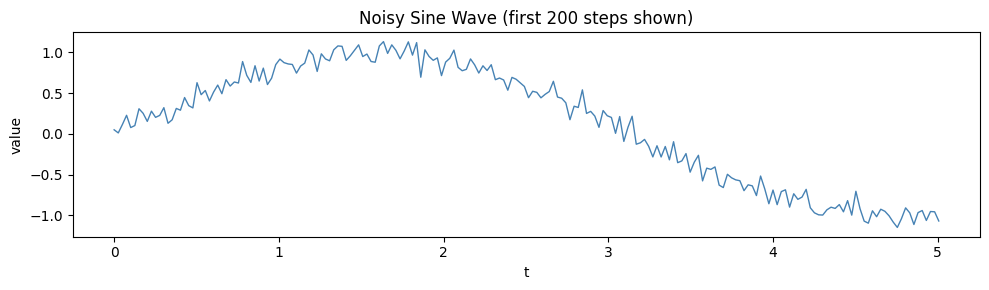

In [16]:
# Generate a noisy sine wave
np.random.seed(42)
t = np.linspace(0, 8 * np.pi, 1000)
signal = np.sin(t) + np.random.normal(0, 0.1, len(t))

plt.figure(figsize=(10, 3))
plt.plot(t[:200], signal[:200], color='steelblue', linewidth=1)
plt.title('Noisy Sine Wave (first 200 steps shown)')
plt.xlabel('t')
plt.ylabel('value')
plt.tight_layout()
plt.show()

In [17]:
# Build sequences: given SEQ_LEN past values, predict the next one
SEQ_LEN = 20

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_seq, y_seq = make_sequences(signal, SEQ_LEN)

# Split
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

# PyTorch expects shape (batch, seq_len, input_size) — add a feature dimension
X_tr_t = torch.tensor(X_tr).unsqueeze(-1)  # (N, 20, 1)
y_tr_t = torch.tensor(y_tr).unsqueeze(-1)  # (N, 1)
X_te_t = torch.tensor(X_te).unsqueeze(-1)
y_te_t = torch.tensor(y_te).unsqueeze(-1)

print(f"X_train shape: {X_tr_t.shape}  — (samples, seq_len, features)")
print(f"y_train shape: {y_tr_t.shape}")

X_train shape: torch.Size([784, 20, 1])  — (samples, seq_len, features)
y_train shape: torch.Size([784, 1])


Now let's define the RNN model. The key difference from a feedforward net:
- `nn.RNN` takes a sequence and returns **outputs at every step** plus the **final hidden state**
- We only care about the output at the **last time step** — that's our prediction
- We initialize the hidden state to zeros at the start of each batch

In [18]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True    # input shape: (batch, seq_len, features)
        )
        self.fc = nn.Linear(hidden_size, 1)  # map final hidden state → prediction

    def forward(self, x):
        batch_size = x.size(0)

        # Initialize hidden state to zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)

        # Forward pass through RNN
        # out shape: (batch, seq_len, hidden_size)
        # hn  shape: (num_layers, batch, hidden_size)
        out, hn = self.rnn(x, h0)

        # Take the output at the LAST time step only
        last_out = out[:, -1, :]   # (batch, hidden_size)

        return self.fc(last_out)   # (batch, 1)

rnn_model = RNNModel()
print(rnn_model)

RNNModel(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [19]:
torch.manual_seed(42)

rnn_model = RNNModel(hidden_size=32)
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=1e-3)

seq_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True
)

rnn_losses = []

for epoch in range(80):
    rnn_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in seq_loader:
        optimizer.zero_grad()
        preds = rnn_model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(seq_loader)
    rnn_losses.append(avg)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:>3}/80  |  Train MSE: {avg:.4f}")

Epoch  20/80  |  Train MSE: 0.0147
Epoch  40/80  |  Train MSE: 0.0136
Epoch  60/80  |  Train MSE: 0.0134
Epoch  80/80  |  Train MSE: 0.0129


Test RMSE: 0.1101


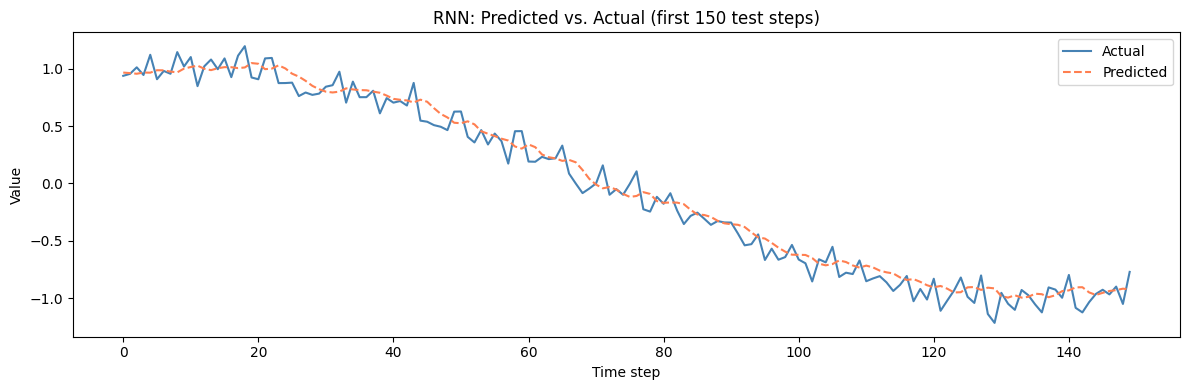

In [20]:
rnn_model.eval()
with torch.no_grad():
    test_preds_rnn = rnn_model(X_te_t).squeeze().numpy()
    test_mse_rnn   = criterion(rnn_model(X_te_t), y_te_t).item()

print(f"Test RMSE: {test_mse_rnn**0.5:.4f}")

# Plot predictions vs. actual
actual = y_te_t.squeeze().numpy()

plt.figure(figsize=(12, 4))
plt.plot(actual[:150],       label='Actual',    color='steelblue', linewidth=1.5)
plt.plot(test_preds_rnn[:150], label='Predicted', color='coral',    linewidth=1.5, linestyle='--')
plt.title('RNN: Predicted vs. Actual (first 150 test steps)')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

#### Regular RNNs & Memory

RNNs work well for short sequences, but struggle with **long-range dependencies** — gradients tend to vanish or explode as they're backpropagated through many time steps.

In practice, two variants are almost always preferred:
- **LSTM** (Long Short-Term Memory) — adds gating mechanisms to control what to remember and forget. Use `nn.LSTM` — same API, just replace `nn.RNN`.
- **GRU** (Gated Recurrent Unit) — a simpler version of LSTM, often just as good. Use `nn.GRU`.

All three share the same interface in PyTorch, so switching between them is just one line.

## Assignment Section

<!-- BEGIN QUESTION -->

**Question 1.**
This tutorial is pretty heavy... go back through and comment any line you don't understand, then work through the notebook again. If there is still anything you don't understand, leave it below, and I will try to help!

Thank you for this tutorial. I find it a good introduction to the coding using pytorch. Especially I liked the implementation of Automatic Differentiation (Autograd). Though I use python for coding in my research, I didn't have any idea that we can directly calculate gradients in this way.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

**Question 2.**

I am five free points, as long as you run me!


In [21]:
x = 5

In [22]:
grader.check("q2")

q2 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [23]:
grader.check_all()

q2 results: All test cases passed!